# Stage 2 Portfolio Insurance Playground

Use this notebook to inspect the fetched TSETMC/Wallex snapshot, validate point-in-time data, run VPPI policies, audit orders and holdings, compare baselines, and explore the parameter surface.

Default instruments: **لبخند** (fixed income), **طلا** (gold), **آگاس** (equity), and Wallex **USDTTMN** converted to IRR. Change `SNAPSHOT_NAME` below to use another saved snapshot.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from portfolio_insurance.backtest import (
    BacktestPolicy,
    ExecutionModel,
    ReviewFrequency,
    Strategy,
    attribute_effects,
    run_backtest,
    run_baselines,
)
from portfolio_insurance.config import load_project_config
from portfolio_insurance.cost_config import load_asset_transaction_costs
from portfolio_insurance.data_contract import load_data_contract
from portfolio_insurance.data_quality import validate_market_data
from portfolio_insurance.data_sources import load_snapshot, point_in_time_prices
from portfolio_insurance.experiments import export_experiment, run_parameter_grid

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Locate and load a snapshot

The root detection works whether Jupyter starts in the repository root or in `notebooks/`. If the smoke snapshot is absent, run the fetch command printed by the error.

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Start JupyterLab in the Portfolio Risk Insurance System repository.")

SNAPSHOT_NAME = "live_smoke"
SNAPSHOT_PATH = ROOT / "data" / "snapshots" / SNAPSHOT_NAME
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(
        f"{SNAPSHOT_PATH} does not exist. Run:\n"
        "portfolio-insurance fetch-data --start 2024-01-01 --end 2026-08-20 "
        f"--output {SNAPSHOT_PATH}"
    )

config = load_project_config(ROOT / "configs" / "portfolios.toml")
contract = load_data_contract(ROOT / "configs" / "data_contract.toml")
snapshot = load_snapshot(SNAPSHOT_PATH)
active_snapshot_data = snapshot.data.loc[snapshot.data["series"].isin(contract.series)].copy()

print(f"Repository: {ROOT}")
print(f"Snapshot:   {SNAPSHOT_PATH}")

Repository: C:\Users\Admin\Documents\ChatGPT\Portfolio Risk Insurance System
Snapshot:   C:\Users\Admin\Documents\ChatGPT\Portfolio Risk Insurance System\data\snapshots\live_smoke


In [3]:
display(pd.Series({
    "fetched_at": snapshot.manifest.fetched_at,
    "start": snapshot.manifest.start,
    "end": snapshot.manifest.end,
    "rows": snapshot.manifest.row_count,
    "currency": snapshot.manifest.currency,
    "wallex_symbol": snapshot.manifest.wallex_symbol,
    "sha256": snapshot.manifest.sha256,
}, name="snapshot manifest").to_frame())
display(pd.Series({key: value for key, value in snapshot.manifest.tse_symbols.items() if key in contract.series}, name="TSETMC symbol").to_frame())

,snapshot manifest
fetched_at,2026-08-23T12:12:47.913405+00:00
start,2026-08-01
end,2026-08-20
rows,75
currency,IRR
wallex_symbol,USDTTMN
sha256,2e3dec37c652c0a5b1fd70c3af62c885f939eff41fc76a...


,TSETMC symbol
equity_tr,آگاس
fixed_income_tr,لبخند
gold_tr,طلا


## 2. Inspect and validate point-in-time data

In [4]:
display(active_snapshot_data.head(10))
overview = active_snapshot_data.groupby("series").agg(
    first_valuation=("valuation_at", "min"),
    last_valuation=("valuation_at", "max"),
    observations=("value", "size"),
    minimum=("value", "min"),
    maximum=("value", "max"),
)
display(overview)

,series,valuation_at,observed_at,available_at,value
0,equity_tr,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,362880.0
1,fixed_income_tr,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,29475.0
2,gold_tr,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,2026-08-01 12:30:00+00:00,1326244.0
4,usd_irr,2026-08-01 12:30:00+00:00,2026-08-01 12:00:00+00:00,2026-08-01 12:00:00+00:00,1945530.0
5,equity_tr,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,373485.0
6,fixed_income_tr,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,29503.0
7,gold_tr,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,2026-08-02 12:30:00+00:00,1294610.0
9,usd_irr,2026-08-02 12:30:00+00:00,2026-08-02 12:00:00+00:00,2026-08-02 12:00:00+00:00,1923010.0
10,equity_tr,2026-08-03 12:30:00+00:00,2026-08-03 12:30:00+00:00,2026-08-03 12:30:00+00:00,384689.0
11,fixed_income_tr,2026-08-03 12:30:00+00:00,2026-08-03 12:30:00+00:00,2026-08-03 12:30:00+00:00,29556.0


,first_valuation,last_valuation,observations,minimum,maximum
series,,,,,
equity_tr,2026-08-01 12:30:00+00:00,2026-08-19 12:30:00+00:00,15,362880.0,432341.0
fixed_income_tr,2026-08-01 12:30:00+00:00,2026-08-19 12:30:00+00:00,15,29475.0,29997.0
gold_tr,2026-08-01 12:30:00+00:00,2026-08-19 12:30:00+00:00,15,1291212.0,1406853.0
usd_irr,2026-08-01 12:30:00+00:00,2026-08-19 12:30:00+00:00,15,1856030.0,1945530.0


In [5]:
quality = validate_market_data(
    active_snapshot_data,
    contract,
    snapshot.manifest.start,
    snapshot.manifest.end,
    series_keys=set(active_snapshot_data["series"]),
)
display(pd.Series(quality.coverage, name="coverage").to_frame())
display(pd.DataFrame([
    {"code": issue.code, "severity": issue.severity, "message": issue.message, "series": issue.series}
    for issue in quality.issues
]))
quality.raise_for_errors()
print("✓ Snapshot passed coverage, staleness, value, publication, and look-ahead checks.")

,coverage
fixed_income_tr,1.0
gold_tr,1.0
equity_tr,1.0
usd_irr,1.0


""


✓ Snapshot passed coverage, staleness, value, publication, and look-ahead checks.


## 3. Build and visualize the medium-term price table

,strategic weight
fixed_income,0.3
gold,0.4
equity,0.3


asset,fixed_income,gold,equity
valuation_at,,,
2026-08-15 12:30:00+00:00,29845.0,1351845.0,414700.0
2026-08-16 12:30:00+00:00,29883.0,1347988.0,420448.0
2026-08-17 12:30:00+00:00,29921.0,1356466.0,432341.0
2026-08-18 12:30:00+00:00,29959.0,1374071.0,430577.0
2026-08-19 12:30:00+00:00,29997.0,1406853.0,431068.0


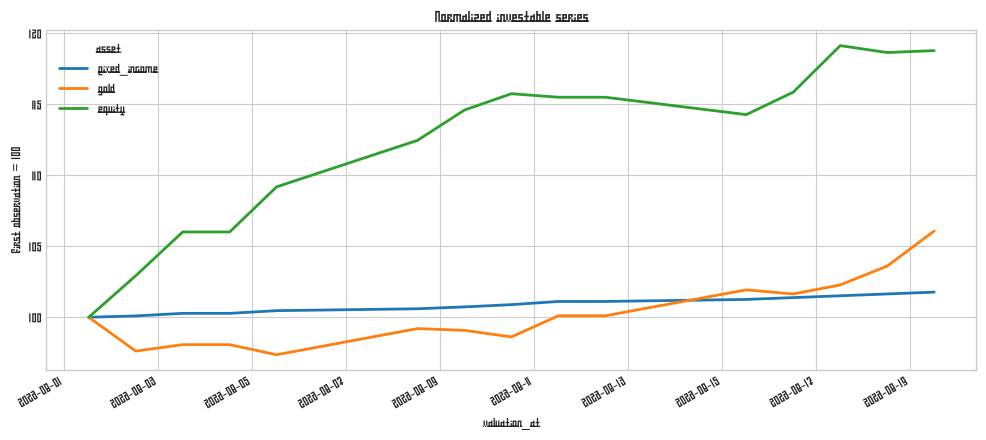

In [6]:
portfolio = config.portfolios["medium_term"]
prices = point_in_time_prices(active_snapshot_data, contract, list(portfolio.weights))
display(pd.Series(dict(portfolio.weights), name="strategic weight").to_frame())
display(prices.tail())

normalized = prices.div(prices.iloc[0]).mul(100)
ax = normalized.plot(figsize=(12, 5), linewidth=2)
ax.set(title="Normalized investable series", ylabel="First observation = 100")
plt.show()

## 4. Run one VPPI policy

Edit the parameters and rerun this cell to play with the policy. Decisions use information at a close and can execute only on a later bar.

In [7]:
policy = BacktestPolicy(
    strategy=Strategy.VPPI,
    multiplier=3.0,
    floor_fraction=0.80,
    review_frequency=ReviewFrequency.WEEKLY,
    drift_band=0.02,
    execution=ExecutionModel(
        slippage_bps=5,
        latency_bars=1,
        asset_costs=load_asset_transaction_costs(ROOT / "configs" / "transaction_costs.toml"),
    ),
    reserve_daily_return=config.assets["fixed_income"].daily_return,
    reserve_calendar_day_accrual=config.assets["fixed_income"].calendar_day_accrual,
)
result = run_backtest(prices, portfolio.weights, policy, initial_nav=1_000_000)
display(pd.Series(result.summary, name="value").to_frame())
display(pd.Series(result.metadata, name="value").to_frame())

,value
ending_nav,1.062338e+06
total_return,6.233848e-02
annualized_volatility,5.958760e-02
sharpe_ratio,1.711157e+01
sortino_ratio,2.289497e+02
maximum_drawdown,-1.086553e-03
expected_shortfall_95,-1.086553e-03
turnover,7.647775e-01
total_cost,9.461397e+02
total_transaction_cost,5.603790e+02


,value
run_id,bf3d83d1-7344-5835-889b-96a33fea0327
data_sha256,3855288895d28933e2c4503ca72fb8d0f51391843891e1...
tradability_sha256,c0e8d30db234dad61c1cfca633f5925b7572fbc0ec01fe...
policy,"{'strategy': 'vppi', 'review_frequency': 'week..."
strategic_weights,"{'fixed_income': 0.3, 'gold': 0.4, 'equity': 0.3}"
initial_nav,1000000
first_timestamp,2026-08-01T12:30:00+00:00
last_timestamp,2026-08-19T12:30:00+00:00
observations,15
timing,"close-to-close return, then prior order at clo..."


## 5. Audit decisions, executions, holdings, and reconciliation

In [8]:
audit_columns = [
    "opening_nav", "gross_nav", "nav", "floor_value",
    "floor_breach", "gap_breach", "reviewed",
    "order_scheduled", "order_executed", "decision_order_id",
    "execution_order_id", "decision_at", "execute_at",
    "blocked_by_pending_order_id", "turnover", "cost",
]
display(result.ledger[audit_columns])

,opening_nav,gross_nav,nav,floor_value,floor_breach,gap_breach,reviewed,order_scheduled,order_executed,decision_order_id,execution_order_id,decision_at,execute_at,blocked_by_pending_order_id,turnover,cost
timestamp,,,,,,,,,,,,,,,,
2026-08-01 12:30:00+00:00,1.000000e+06,1.000000e+06,1.000000e+06,800000.0,False,False,True,True,False,order-000001,NaN,NaT,2026-08-02 12:30:00+00:00,None,0.000000,0.000000
2026-08-02 12:30:00+00:00,1.000000e+06,9.995864e+05,9.989134e+05,800000.0,False,False,False,False,True,NaN,order-000001,2026-08-01 12:30:00+00:00,NaT,None,0.559031,672.985206
2026-08-03 12:30:00+00:00,9.989134e+05,1.006118e+06,1.006118e+06,800000.0,False,False,True,True,False,order-000002,NaN,NaT,2026-08-04 12:30:00+00:00,None,0.000000,0.000000
2026-08-04 12:30:00+00:00,1.006118e+06,1.006814e+06,1.006725e+06,800000.0,False,False,False,False,True,NaN,order-000002,2026-08-03 12:30:00+00:00,NaT,None,0.058384,89.828191
2026-08-05 12:30:00+00:00,1.006725e+06,1.012244e+06,1.012244e+06,800000.0,False,False,False,False,False,NaN,NaN,NaT,NaT,None,0.000000,0.000000
2026-08-08 12:30:00+00:00,1.012244e+06,1.025087e+06,1.025087e+06,800000.0,False,False,False,False,False,NaN,NaN,NaT,NaT,None,0.000000,0.000000
2026-08-09 12:30:00+00:00,1.025087e+06,1.029821e+06,1.029821e+06,800000.0,False,False,False,False,False,NaN,NaN,NaT,NaT,None,0.000000,0.000000
2026-08-10 12:30:00+00:00,1.029821e+06,1.031800e+06,1.031800e+06,800000.0,False,False,True,True,False,order-000003,NaN,NaT,2026-08-11 12:30:00+00:00,None,0.000000,0.000000
2026-08-11 12:30:00+00:00,1.031800e+06,1.035353e+06,1.035257e+06,800000.0,False,False,False,False,True,NaN,order-000003,2026-08-10 12:30:00+00:00,NaT,None,0.078499,96.164595


In [9]:
trade_columns = [
    "execution_order_id", "decision_at",
    "trade_fixed_income", "trade_gold", "trade_equity", "cost",
]
display(result.ledger.loc[result.ledger["order_executed"], trade_columns])

result.verify_ledger()
assert abs(result.ledger.filter(like="weight_").sum(axis=1).sub(1)).max() < 1e-10
assert abs(result.ledger["cost"].sum() - result.summary["total_cost"]) < 1e-8
print("✓ Holdings, weights, costs, NAV, and execution timing reconcile.")

,execution_order_id,decision_at,trade_fixed_income,trade_gold,trade_equity,cost
timestamp,,,,,,
2026-08-02 12:30:00+00:00,order-000001,2026-08-01 12:30:00+00:00,279400.130555,-150558.327202,-128841.803353,672.985206
2026-08-04 12:30:00+00:00,order-000002,2026-08-03 12:30:00+00:00,-9783.391961,-19607.530360,29390.922320,89.828191
2026-08-11 12:30:00+00:00,order-000003,2026-08-10 12:30:00+00:00,-40637.260994,8540.279074,32096.981919,96.164595
2026-08-18 12:30:00+00:00,order-000004,2026-08-17 12:30:00+00:00,-36332.326108,20794.840309,15537.485799,87.161671


✓ Holdings, weights, costs, NAV, and execution timing reconcile.


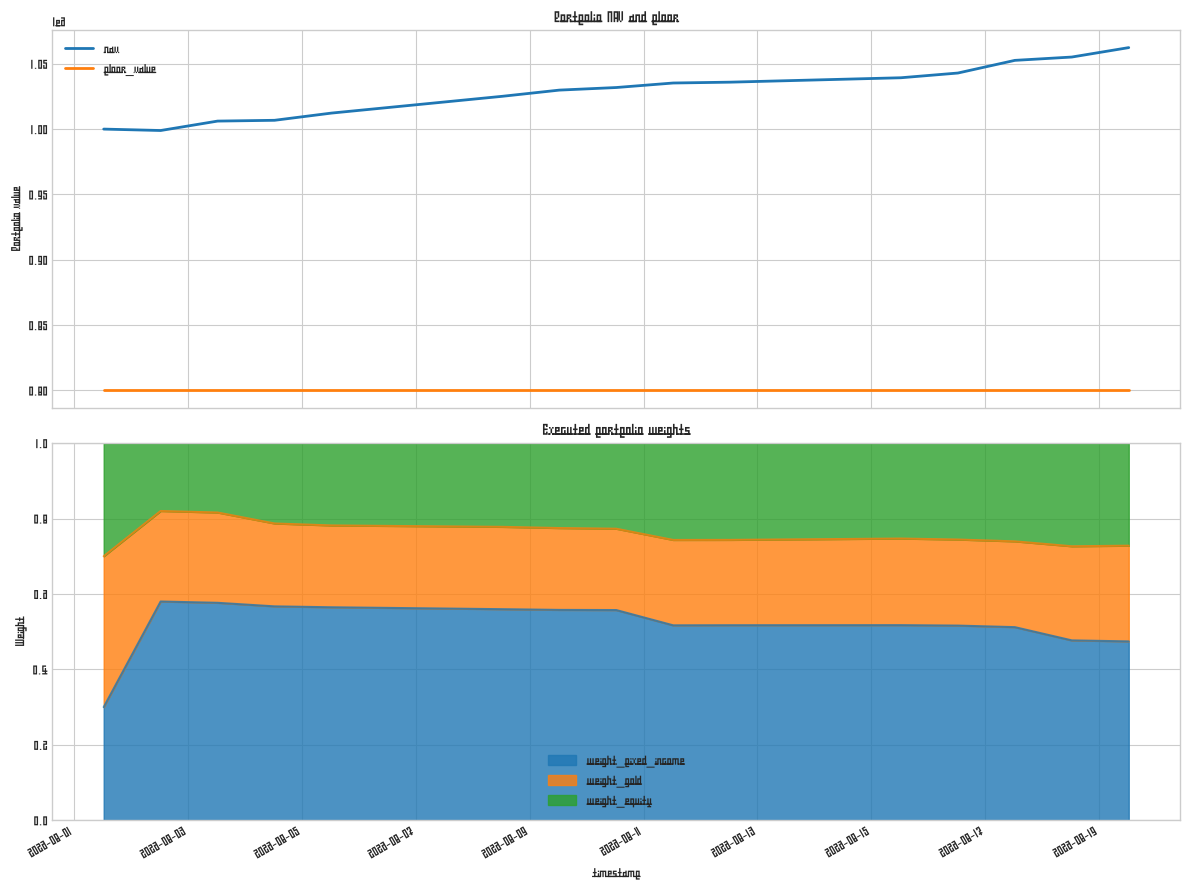

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
result.ledger[["nav", "floor_value"]].plot(ax=axes[0], linewidth=2)
axes[0].set(title="Portfolio NAV and floor", ylabel="Portfolio value")

weight_columns = ["weight_fixed_income", "weight_gold", "weight_equity"]
result.ledger[weight_columns].plot.area(ax=axes[1], stacked=True, alpha=0.8)
axes[1].set(title="Executed portfolio weights", ylabel="Weight", ylim=(0, 1))
plt.tight_layout()
plt.show()

## 6. Compare baselines and inspect exact attribution

,allocation,rebalancing,insurance,cost,reconstructed
timestamp,,,,,
2026-08-15 12:30:00+00:00,0.004487,0.000696,-0.001913,0.000000,0.003264
2026-08-16 12:30:00+00:00,0.003746,-0.000449,0.000178,0.000000,0.003474
2026-08-17 12:30:00+00:00,0.012038,-0.000701,-0.002018,0.000000,0.009288
2026-08-18 12:30:00+00:00,0.003934,0.000381,-0.001805,-0.000083,0.002421
2026-08-19 12:30:00+00:00,0.009902,0.000429,-0.003462,0.000000,0.006838


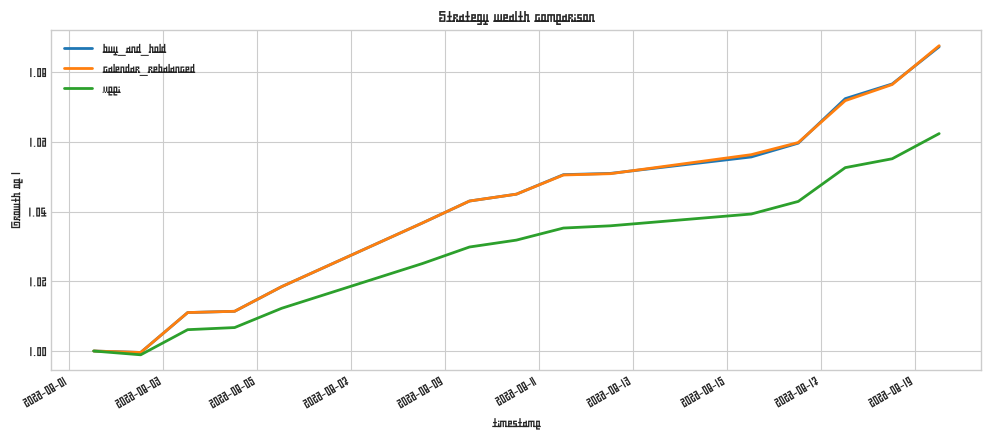

In [11]:
baselines = run_baselines(
    prices,
    portfolio.weights,
    review_frequency=policy.review_frequency,
    drift_band=policy.drift_band,
    execution=policy.execution,
    reserve_daily_return=policy.reserve_daily_return,
    reserve_calendar_day_accrual=policy.reserve_calendar_day_accrual,
)
effects = attribute_effects(
    baselines["buy_and_hold"],
    baselines["calendar_rebalanced"],
    result,
)
assert (effects["reconstructed"] - result.returns).abs().max() < 1e-12
display(effects.tail())

wealth = pd.DataFrame({
    "buy_and_hold": (1 + baselines["buy_and_hold"].returns).cumprod(),
    "calendar_rebalanced": (1 + baselines["calendar_rebalanced"].returns).cumprod(),
    "vppi": (1 + result.returns).cumprod(),
})
wealth.plot(figsize=(12, 5), linewidth=2, title="Strategy wealth comparison")
plt.ylabel("Growth of 1")
plt.show()

## 7. Explore the local and USD-relative parameter surface

This grid is deliberately small enough for interactive use. Add values to any list to expand it.

In [12]:
usd_reference = (
    active_snapshot_data.loc[active_snapshot_data["series"] == "usd_irr"]
    .set_index("valuation_at")["value"]
    .sort_index()
)
grid = run_parameter_grid(
    prices,
    portfolio.weights,
    multipliers=[2, 3, 4],
    floors=[0.75, 0.80, 0.90],
    frequencies=[
        ReviewFrequency.DAILY,
        ReviewFrequency.WEEKLY,
        ReviewFrequency.BIWEEKLY,
        ReviewFrequency.MONTHLY,
    ],
    drift_bands=[0.02, 0.05],
    execution=policy.execution,
    reference_prices=usd_reference,
    reserve_daily_return=policy.reserve_daily_return,
    reserve_calendar_day_accrual=policy.reserve_calendar_day_accrual,
)
print(f"Completed {len(grid.table)} deterministic runs.")

Completed 144 deterministic runs.


In [13]:
result_columns = [
    "scenario", "multiplier", "floor_fraction", "review_frequency",
    "drift_band", "total_return", "maximum_drawdown",
    "turnover", "total_cost", "ever_breached",
]
ranked = grid.table.sort_values(
    ["scenario", "total_return", "maximum_drawdown"],
    ascending=[True, False, False],
)
display(ranked[result_columns].head(20))

,scenario,multiplier,floor_fraction,review_frequency,drift_band,total_return,maximum_drawdown,turnover,total_cost,ever_breached
17,local,4,0.75,biweekly,0.05,0.087231,-0.000414,0.000000,0.000000,0.0
19,local,4,0.75,daily,0.05,0.087231,-0.000414,0.000000,0.000000,0.0
20,local,4,0.75,monthly,0.02,0.087231,-0.000414,0.000000,0.000000,0.0
21,local,4,0.75,monthly,0.05,0.087231,-0.000414,0.000000,0.000000,0.0
23,local,4,0.75,weekly,0.05,0.087231,-0.000414,0.000000,0.000000,0.0
18,local,4,0.75,daily,0.02,0.085720,-0.000414,0.116641,160.120001,0.0
16,local,4,0.75,biweekly,0.02,0.085472,-0.000414,0.103417,147.752560,0.0
22,local,4,0.75,weekly,0.02,0.085472,-0.000414,0.103417,147.752560,0.0
42,local,4,0.80,daily,0.02,0.077587,-0.000749,0.487465,623.114144,0.0
40,local,4,0.80,biweekly,0.02,0.076877,-0.000749,0.459677,592.964903,0.0


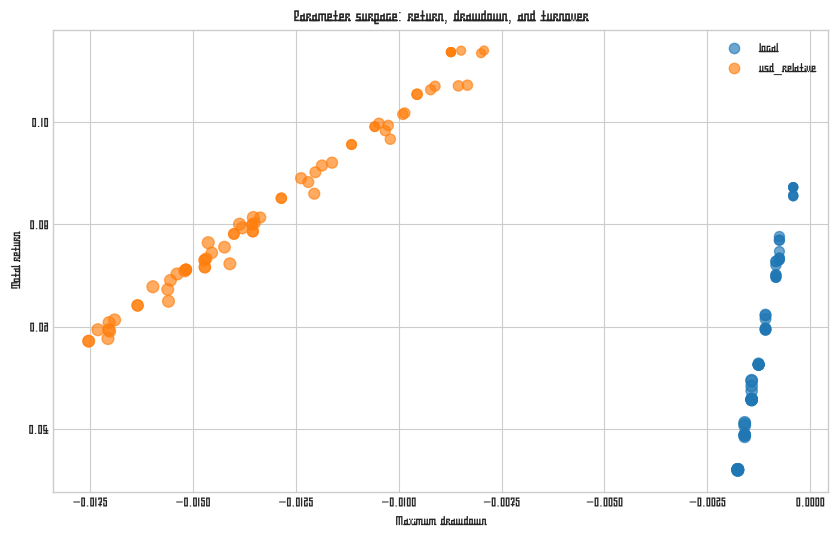

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for scenario, frame in grid.table.groupby("scenario"):
    ax.scatter(
        frame["maximum_drawdown"],
        frame["total_return"],
        s=40 + frame["turnover"] * 25,
        alpha=0.65,
        label=scenario,
    )
ax.set(
    title="Parameter surface: return, drawdown, and turnover",
    xlabel="Maximum drawdown",
    ylabel="Total return",
)
ax.legend()
plt.show()

## 8. Optionally export the interactive grid

Set `EXPORT_RESULTS = True` to write every run's ledger, attribution, metadata, summary, and baseline ledgers.

In [15]:
EXPORT_RESULTS = False
if EXPORT_RESULTS:
    export_path = export_experiment(grid, ROOT / "runs" / "notebook_playground")
    print(f"Exported results to {export_path}")
else:
    print("Nothing exported. Change EXPORT_RESULTS to True when desired.")

Nothing exported. Change EXPORT_RESULTS to True when desired.


## 9. Switch to the long-term portfolio

The long-term portfolio assigns 10% to fixed income, 50% to gold, and 40% to equity. This cell verifies its input table and default VPPI run.

In [16]:
long_term = config.portfolios["long_term"]
long_prices = point_in_time_prices(active_snapshot_data, contract, list(long_term.weights))
long_result = run_backtest(long_prices, long_term.weights, policy)
display(pd.Series(dict(long_term.weights), name="strategic weight").to_frame())
display(pd.Series(long_result.summary, name="value").to_frame())
print("✓ Long-term three-asset portfolio ran and reconciled.")

,strategic weight
fixed_income,0.1
gold,0.5
equity,0.4


,value
ending_nav,1.075678e+06
total_return,7.567780e-02
annualized_volatility,7.475825e-02
sharpe_ratio,1.646843e+01
sortino_ratio,3.056607e+02
maximum_drawdown,-9.826913e-04
expected_shortfall_95,-9.826913e-04
turnover,1.001272e+00
total_cost,1.239639e+03
total_transaction_cost,7.331907e+02


✓ Long-term three-asset portfolio ran and reconciled.


## Useful terminal commands

Run these from a JupyterLab terminal or PowerShell in the repository root:

```powershell
uv run python -m unittest discover -s tests -v
uv run ruff check src tests
uv run portfolio-insurance validate-data --snapshot data/snapshots/live_smoke
```

The notebook is a research interface, not evidence that any historical close was executable or that VPPI guarantees its floor.